In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/KECERDASAN BUATAN/UAS Kecerdasan Buatan/Dataset.zip"))

False


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive"):
    if "Dataset.zip" in files:
        print(os.path.join(root, "Dataset.zip"))

/content/drive/MyDrive/SEMESTER 4/KECERDASAN BUATAN /UAS Kecerdasan Buatan/Dataset.zip


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "Dataset.zip" in files:
        zip_path = os.path.join(root, "Dataset.zip")
        print(zip_path)
        break

/content/drive/MyDrive/SEMESTER 4/KECERDASAN BUATAN /UAS Kecerdasan Buatan/Dataset.zip


In [ ]:
import zipfile

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Ekstraksi berhasil!")
print(os.listdir(extract_path))

Ekstraksi berhasil!
['rice leaf diseases dataset']


In [ ]:
import os

print(os.listdir("/content/dataset"))


['rice leaf diseases dataset']


In [ ]:
dataset_path = "/content/dataset/Dataset"

In [ ]:
# Install semua library yang dibutuhkan
!pip install numpy opencv-python matplotlib seaborn scikit-learn scikit-image pandas tqdm joblib

In [ ]:
# ========================================
# Cell 1: Import Library
# ========================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from skimage.feature import local_binary_pattern
import joblib
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [ ]:
# ========================================
# CELL 2: EKSTRAK DATASET
# ========================================
import zipfile
import os

# Path ke file zip
zip_path = '/content/drive/MyDrive/SEMESTER 4/KECERDASAN BUATAN /UAS Kecerdasan Buatan/Dataset.zip'

# Tujuan ekstrak
extract_path = '/content/dataset'

# Ekstrak file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"✅ Dataset berhasil diekstrak ke: {extract_path}")

# Lihat isi folder hasil ekstrak
print("\nIsi folder dataset:")
print(os.listdir(extract_path))

✅ Dataset berhasil diekstrak ke: /content/dataset

Isi folder dataset:
['rice leaf diseases dataset']


In [ ]:
# ========================================
# CELL 3: EKSPLORASI AWAL DATASET
# ========================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Path dataset (sesuaikan jika perlu)
dataset_path = '/content/dataset'

# Cari semua folder di dalam dataset
# Karena mungkin ada folder di dalam folder, kita cari
all_folders = []
for root, dirs, files in os.walk(dataset_path):
    for dir_name in dirs:
        # Cek apakah folder berisi file gambar
        dir_path = os.path.join(root, dir_name)
        images = [f for f in os.listdir(dir_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if len(images) > 0:
            all_folders.append((dir_name, dir_path, len(images)))

# Tampilkan hasil
print("📁 STRUKTUR DATASET:")
print("=" * 50)
for folder_name, folder_path, count in all_folders:
    print(f"  📂 {folder_name}: {count} gambar")
    print(f"     Path: {folder_path}")

# Tentukan folder utama dataset
if all_folders:
    main_dataset_path = all_folders[0][1].split('/')[0] + '/' + all_folders[0][1].split('/')[1]
    print(f"\n✅ Dataset utama: {main_dataset_path}")

📁 STRUKTUR DATASET:
  📂 Bacterialblight: 1604 gambar
     Path: /content/dataset/rice leaf diseases dataset/Bacterialblight
  📂 Leafsmut: 1460 gambar
     Path: /content/dataset/rice leaf diseases dataset/Leafsmut
  📂 Brownspot: 1620 gambar
     Path: /content/dataset/rice leaf diseases dataset/Brownspot

✅ Dataset utama: /content


In [ ]:
# ========================================
# CELL 4: BUAT DATAFRAME DARI DATASET
# ========================================

image_paths = []
labels = []

# Loop untuk mengumpulkan semua gambar
for folder_name, folder_path, count in all_folders:
    for img_file in os.listdir(folder_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(folder_path, img_file))
            labels.append(folder_name)

# Buat DataFrame
df = pd.DataFrame({
    'image_path': image_paths,
    'label': labels
})

print(f"✅ Total gambar: {len(df)}")
print(f"✅ Jumlah kelas: {len(df['label'].unique())}")
print("\nDistribusi kelas:")
print(df['label'].value_counts())

# Tampilkan 5 data pertama
print("\n5 Data pertama:")
print(df.head())

# Simpan info dataset
df.to_csv('/content/dataset_info.csv', index=False)
print("\n✅ Dataset info disimpan ke 'dataset_info.csv'")

✅ Total gambar: 4684
✅ Jumlah kelas: 3

Distribusi kelas:
label
Brownspot          1620
Bacterialblight    1604
Leafsmut           1460
Name: count, dtype: int64

5 Data pertama:
                                          image_path            label
0  /content/dataset/rice leaf diseases dataset/Ba...  Bacterialblight
1  /content/dataset/rice leaf diseases dataset/Ba...  Bacterialblight
2  /content/dataset/rice leaf diseases dataset/Ba...  Bacterialblight
3  /content/dataset/rice leaf diseases dataset/Ba...  Bacterialblight
4  /content/dataset/rice leaf diseases dataset/Ba...  Bacterialblight

✅ Dataset info disimpan ke 'dataset_info.csv'


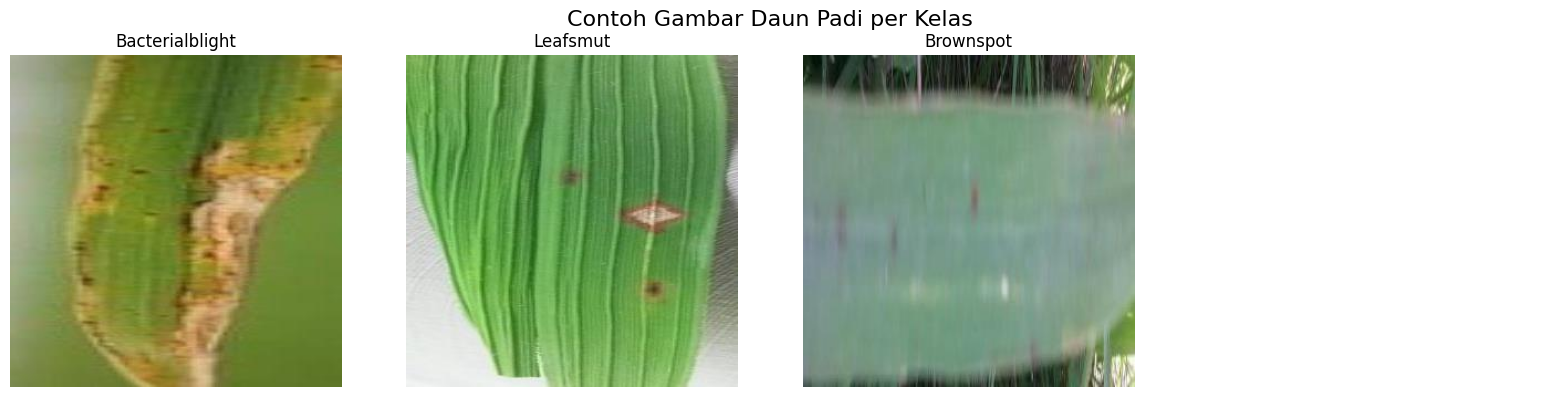

✅ Gambar contoh disimpan ke 'sample_images.png'


In [ ]:
# ========================================
# CELL 5: TAMPILKAN CONTOH GAMBAR PER KELAS
# ========================================

# Pilih beberapa kelas
unique_labels = df['label'].unique()
num_classes = len(unique_labels)
cols = 4
rows = (num_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = axes.flatten()

for idx, label in enumerate(unique_labels):
    # Ambil 1 gambar dari kelas tersebut
    sample = df[df['label'] == label].iloc[0]
    img = cv2.imread(sample['image_path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[idx].imshow(img)
    axes[idx].set_title(f"{label}", fontsize=12)
    axes[idx].axis('off')

# Sembunyikan subplot kosong
for idx in range(num_classes, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Contoh Gambar Daun Padi per Kelas', fontsize=16)
plt.tight_layout()
plt.savefig('/content/sample_images.png')
plt.show()

print("✅ Gambar contoh disimpan ke 'sample_images.png'")

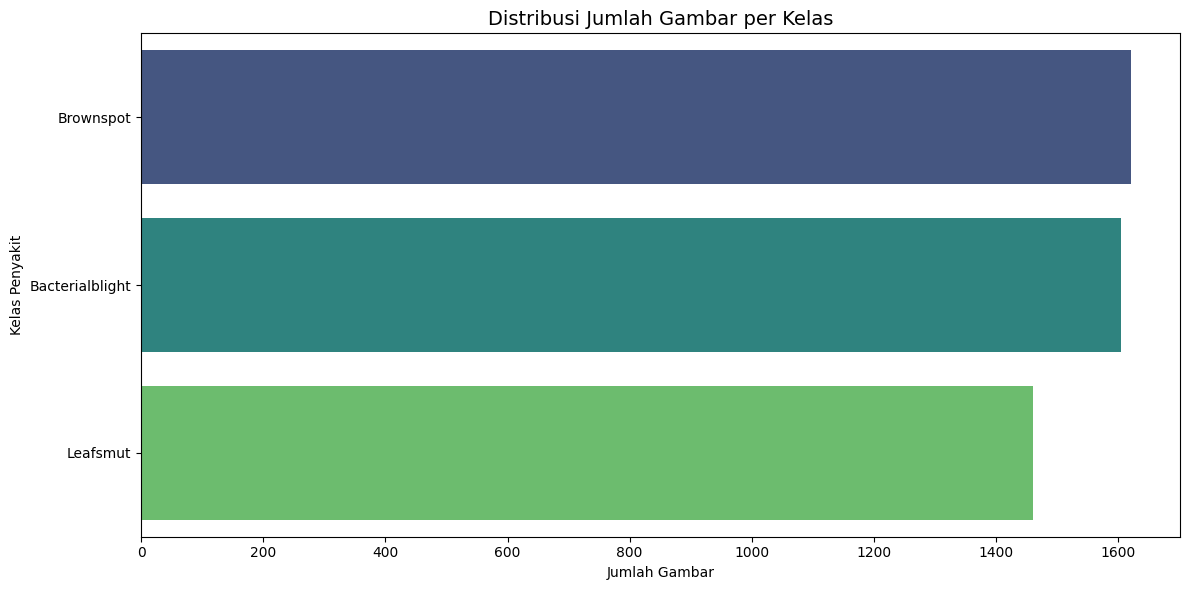

✅ Distribusi kelas disimpan ke 'distribusi_kelas.png'


In [ ]:
# ========================================
# CELL 6: VISUALISASI DISTRIBUSI KELAS
# ========================================

plt.figure(figsize=(12, 6))
class_counts = df['label'].value_counts()
sns.barplot(x=class_counts.values, y=class_counts.index, palette='viridis')
plt.title('Distribusi Jumlah Gambar per Kelas', fontsize=14)
plt.xlabel('Jumlah Gambar')
plt.ylabel('Kelas Penyakit')
plt.tight_layout()
plt.savefig('/content/distribusi_kelas.png')
plt.show()

print("✅ Distribusi kelas disimpan ke 'distribusi_kelas.png'")

In [ ]:
# ========================================
# CELL 7: SIMPAN HASIL KE DRIVE
# ========================================

# Tentukan folder tujuan di Drive
save_path = '/content/drive/MyDrive/SEMESTER 4/KECERDASAN BUATAN /UAS Kecerdasan Buatan/Hasil/'

# Buat folder jika belum ada
os.makedirs(save_path, exist_ok=True)

# Simpan file
df.to_csv(save_path + 'dataset_info.csv', index=False)
print(f"✅ Dataset info disimpan di: {save_path}dataset_info.csv")

# Salin gambar hasil visualisasi
import shutil
shutil.copy('/content/sample_images.png', save_path + 'sample_images.png')
shutil.copy('/content/distribusi_kelas.png', save_path + 'distribusi_kelas.png')
print(f"✅ Visualisasi disimpan di: {save_path}")

print("\n✅ Semua file berhasil disimpan ke Google Drive!")

✅ Dataset info disimpan di: /content/drive/MyDrive/SEMESTER 4/KECERDASAN BUATAN /UAS Kecerdasan Buatan/Hasil/dataset_info.csv
✅ Visualisasi disimpan di: /content/drive/MyDrive/SEMESTER 4/KECERDASAN BUATAN /UAS Kecerdasan Buatan/Hasil/

✅ Semua file berhasil disimpan ke Google Drive!


In [ ]:
# ========================================
# CELL 8: EKSTRAKSI FITUR DARI GAMBAR
# ========================================

import cv2
import numpy as np
import pandas as pd
from skimage.feature import local_binary_pattern
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Fungsi ekstraksi fitur
def extract_features(image_path):
    """
    Ekstrak fitur dari gambar daun padi:
    - Fitur Warna (RGB Histogram)
    - Fitur Tekstur (LBP)
    - Fitur Bentuk (Area, Perimeter)
    """
    try:
        # Baca gambar
        img = cv2.imread(image_path)
        if img is None:
            return None

        # Resize ke ukuran seragam
        img = cv2.resize(img, (128, 128))

        # ---- 1. FITUR WARNA (RGB Histogram) ----
        rgb_hist = []
        for i in range(3):
            hist = cv2.calcHist([img], [i], None, [16], [0, 256])
            hist = hist.flatten() / (img.shape[0] * img.shape[1])
            rgb_hist.extend(hist)

        # ---- 2. FITUR TEKSTUR (LBP) ----
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
        lbp_hist = lbp_hist.astype("float")
        lbp_hist /= (lbp_hist.sum() + 1e-7)

        # ---- 3. FITUR BENTUK ----
        _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(largest_contour)
            perimeter = cv2.arcLength(largest_contour, True)
            x, y, w, h = cv2.boundingRect(largest_contour)
            aspect_ratio = w / h if h > 0 else 0
        else:
            area, perimeter, aspect_ratio = 0, 0, 0

        # Gabungkan semua fitur
        features = list(rgb_hist) + list(lbp_hist) + [area, perimeter, aspect_ratio]
        return features

    except Exception as e:
        return None

# ---- EKSEKUSI EKSTRAKSI ----
print("🔄 Memulai ekstraksi fitur...")
print(f"Total gambar: {len(df)}")

X_features = []
y_labels = []
failed = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Ekstraksi"):
    features = extract_features(row['image_path'])
    if features is not None:
        X_features.append(features)
        y_labels.append(row['label'])
    else:
        failed.append(row['image_path'])

print(f"\n✅ Ekstraksi selesai!")
print(f"   - Berhasil: {len(X_features)} gambar")
print(f"   - Gagal: {len(failed)} gambar")

# Buat DataFrame fitur
feature_names = [f'color_{i}' for i in range(48)] + [f'texture_{i}' for i in range(10)] + ['area', 'perimeter', 'aspect_ratio']
df_features = pd.DataFrame(X_features, columns=feature_names)
df_features['label'] = y_labels

print(f"\nShape DataFrame fitur: {df_features.shape}")
print(df_features.head())

# Simpan ke Drive
save_path = '/content/drive/MyDrive/SEMESTER 4/KECERDASAN BUATAN /UAS Kecerdasan Buatan/Hasil/'
os.makedirs(save_path, exist_ok=True)
df_features.to_csv(save_path + 'extracted_features.csv', index=False)
print(f"\n✅ Fitur disimpan ke: {save_path}extracted_features.csv")

🔄 Memulai ekstraksi fitur...
Total gambar: 4684


Ekstraksi: 100%|██████████| 4684/4684 [00:37<00:00, 125.17it/s]



✅ Ekstraksi selesai!
   - Berhasil: 4684 gambar
   - Gagal: 0 gambar

Shape DataFrame fitur: (4684, 62)
    color_0   color_1   color_2   color_3   color_4   color_5   color_6  \
0  0.007446  0.097168  0.320618  0.235046  0.089050  0.077637  0.051270   
1  0.202637  0.170349  0.182922  0.156982  0.095947  0.067566  0.031921   
2  0.075256  0.119385  0.178833  0.159912  0.114258  0.114868  0.074341   
3  0.199707  0.171570  0.114624  0.100220  0.103027  0.081787  0.061340   
4  0.093994  0.138306  0.310608  0.200562  0.094604  0.030212  0.022522   

    color_7   color_8   color_9  ...  texture_4  texture_5  texture_6  \
0  0.049927  0.042908  0.023254  ...   0.150024   0.201538   0.093506   
1  0.024353  0.021667  0.019348  ...   0.282898   0.153564   0.072449   
2  0.049683  0.022522  0.017517  ...   0.200012   0.139282   0.065002   
3  0.047485  0.041077  0.027710  ...   0.175659   0.103882   0.061768   
4  0.023499  0.026794  0.033325  ...   0.223755   0.130493   0.073120   

   te

In [ ]:
# ========================================
# CELL 9: PREPROCESSING DATA
# ========================================

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import numpy as np
import pandas as pd

# ---- 1. LOAD HASIL EKSTRAKSI FITUR ----
save_path = '/content/drive/MyDrive/SEMESTER 4/KECERDASAN BUATAN /UAS Kecerdasan Buatan/Hasil/'

# Baca file hasil ekstraksi
df_features = pd.read_csv(save_path + 'extracted_features.csv')
print(f"✅ Data fitur dimuat: {df_features.shape}")
print(df_features.head())

# ---- 2. PISAHKAN FITUR DAN LABEL ----
X = df_features.drop('label', axis=1).values
y = df_features['label'].values

print(f"\nFitur shape: {X.shape}")
print(f"Label shape: {y.shape}")
print(f"Unique labels: {np.unique(y)}")

# ---- 3. ENCODING LABEL ----
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\n📋 Mapping Label:")
for i, label in enumerate(le.classes_):
    print(f"   {i} -> {label}")

# ---- 4. CEK DISTRIBUSI KELAS ----
print("\n📊 Distribusi kelas setelah encoding:")
unique, counts = np.unique(y_encoded, return_counts=True)
for u, c in zip(unique, counts):
    print(f"   {le.classes_[u]}: {c} gambar ({c/len(y_encoded)*100:.1f}%)")

# ---- 5. NORMALISASI DATA ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✅ Data setelah normalisasi:")
print(f"   Mean: {X_scaled.mean():.4f}")
print(f"   Std: {X_scaled.std():.4f}")

# ---- 6. SPLIT DATA TRAIN-TEST ----
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\n📂 Split Data:")
print(f"   Training set: {X_train.shape[0]} gambar ({X_train.shape[0]/len(y_encoded)*100:.1f}%)")
print(f"   Testing set:  {X_test.shape[0]} gambar ({X_test.shape[0]/len(y_encoded)*100:.1f}%)")

# ---- 7. SIMPAN DATA YANG SUDAH DI-PREPROCESS ----
# Simpan ke Drive
joblib.dump(scaler, save_path + 'scaler.pkl')
joblib.dump(le, save_path + 'label_encoder.pkl')

np.save(save_path + 'X_train.npy', X_train)
np.save(save_path + 'X_test.npy', X_test)
np.save(save_path + 'y_train.npy', y_train)
np.save(save_path + 'y_test.npy', y_test)

print("\n✅ Semua data preprocessing selesai!")
print(f"   📁 Disimpan di: {save_path}")
print("   - scaler.pkl")
print("   - label_encoder.pkl")
print("   - X_train.npy, X_test.npy, y_train.npy, y_test.npy")

✅ Data fitur dimuat: (4684, 62)
    color_0   color_1   color_2   color_3   color_4   color_5   color_6  \
0  0.007446  0.097168  0.320618  0.235046  0.089050  0.077637  0.051270   
1  0.202637  0.170349  0.182922  0.156982  0.095947  0.067566  0.031921   
2  0.075256  0.119385  0.178833  0.159912  0.114258  0.114868  0.074341   
3  0.199707  0.171570  0.114624  0.100220  0.103027  0.081787  0.061340   
4  0.093994  0.138306  0.310608  0.200562  0.094604  0.030212  0.022522   

    color_7   color_8   color_9  ...  texture_4  texture_5  texture_6  \
0  0.049927  0.042908  0.023254  ...   0.150024   0.201538   0.093506   
1  0.024353  0.021667  0.019348  ...   0.282898   0.153564   0.072449   
2  0.049683  0.022522  0.017517  ...   0.200012   0.139282   0.065002   
3  0.047485  0.041077  0.027710  ...   0.175659   0.103882   0.061768   
4  0.023499  0.026794  0.033325  ...   0.223755   0.130493   0.073120   

   texture_7  texture_8  texture_9     area    perimeter  aspect_ratio  \
0   

📊 STATISTIK DATA TRAIN
Jumlah sampel: 3747
Jumlah fitur: 61

Distribusi label train:
   Bacterialblight: 1283 (34.2%)
   Brownspot: 1296 (34.6%)
   Leafsmut: 1168 (31.2%)

📊 STATISTIK DATA TEST
Jumlah sampel: 937

Distribusi label test:
   Bacterialblight: 321 (34.3%)
   Brownspot: 324 (34.6%)
   Leafsmut: 292 (31.2%)


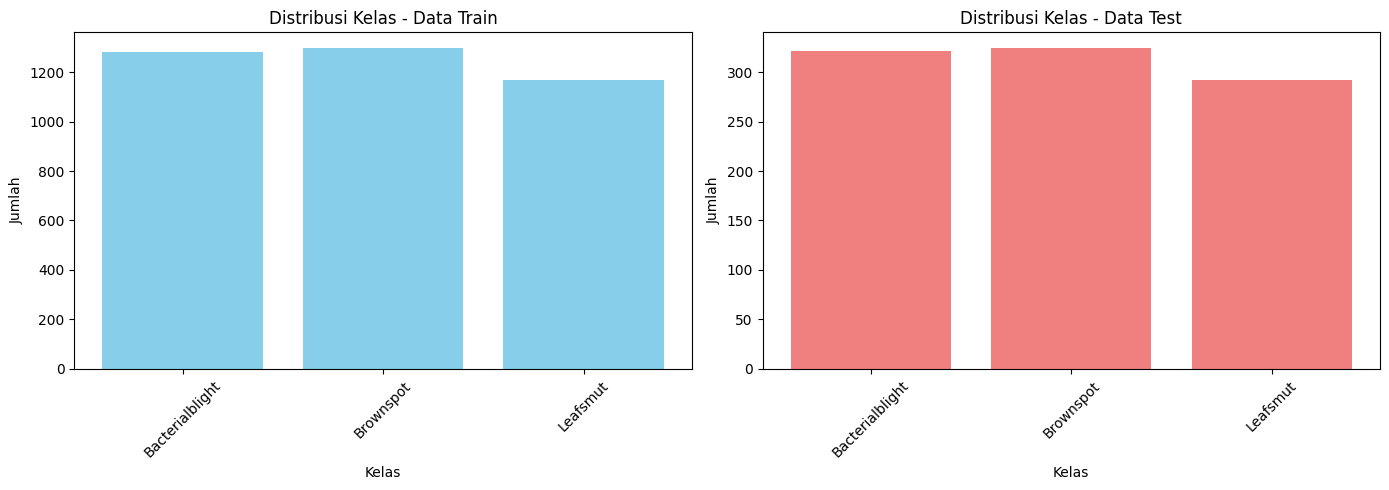


✅ Verifikasi selesai!


In [ ]:
# ========================================
# CELL 10: VERIFIKASI DATA
# ========================================

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 50)
print("📊 STATISTIK DATA TRAIN")
print("=" * 50)
print(f"Jumlah sampel: {len(X_train)}")
print(f"Jumlah fitur: {X_train.shape[1]}")

print("\nDistribusi label train:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for u, c in zip(unique_train, counts_train):
    print(f"   {le.classes_[u]}: {c} ({c/len(X_train)*100:.1f}%)")

print("\n" + "=" * 50)
print("📊 STATISTIK DATA TEST")
print("=" * 50)
print(f"Jumlah sampel: {len(X_test)}")

print("\nDistribusi label test:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for u, c in zip(unique_test, counts_test):
    print(f"   {le.classes_[u]}: {c} ({c/len(X_test)*100:.1f}%)")

# Visualisasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar([le.classes_[u] for u in unique_train], counts_train, color='skyblue')
ax1.set_title('Distribusi Kelas - Data Train')
ax1.set_xlabel('Kelas')
ax1.set_ylabel('Jumlah')
ax1.tick_params(axis='x', rotation=45)

ax2.bar([le.classes_[u] for u in unique_test], counts_test, color='lightcoral')
ax2.set_title('Distribusi Kelas - Data Test')
ax2.set_xlabel('Kelas')
ax2.set_ylabel('Jumlah')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(save_path + 'distribusi_train_test.png')
plt.show()

print("\n✅ Verifikasi selesai!")

✅ Data berhasil dimuat:
   X_train: (3747, 61)
   X_test: (937, 61)
   y_train: (3747,)
   y_test: (937,)

🌳 MODEL 1: DECISION TREE
✅ Decision Tree berhasil dilatih!

🔍 MODEL 2: K-NEAREST NEIGHBORS (KNN)
✅ KNN berhasil dilatih!

✅ Model disimpan di: /content/drive/MyDrive/SEMESTER 4/KECERDASAN BUATAN /UAS Kecerdasan Buatan/Hasil/
   - decision_tree_model.pkl
   - knn_model.pkl


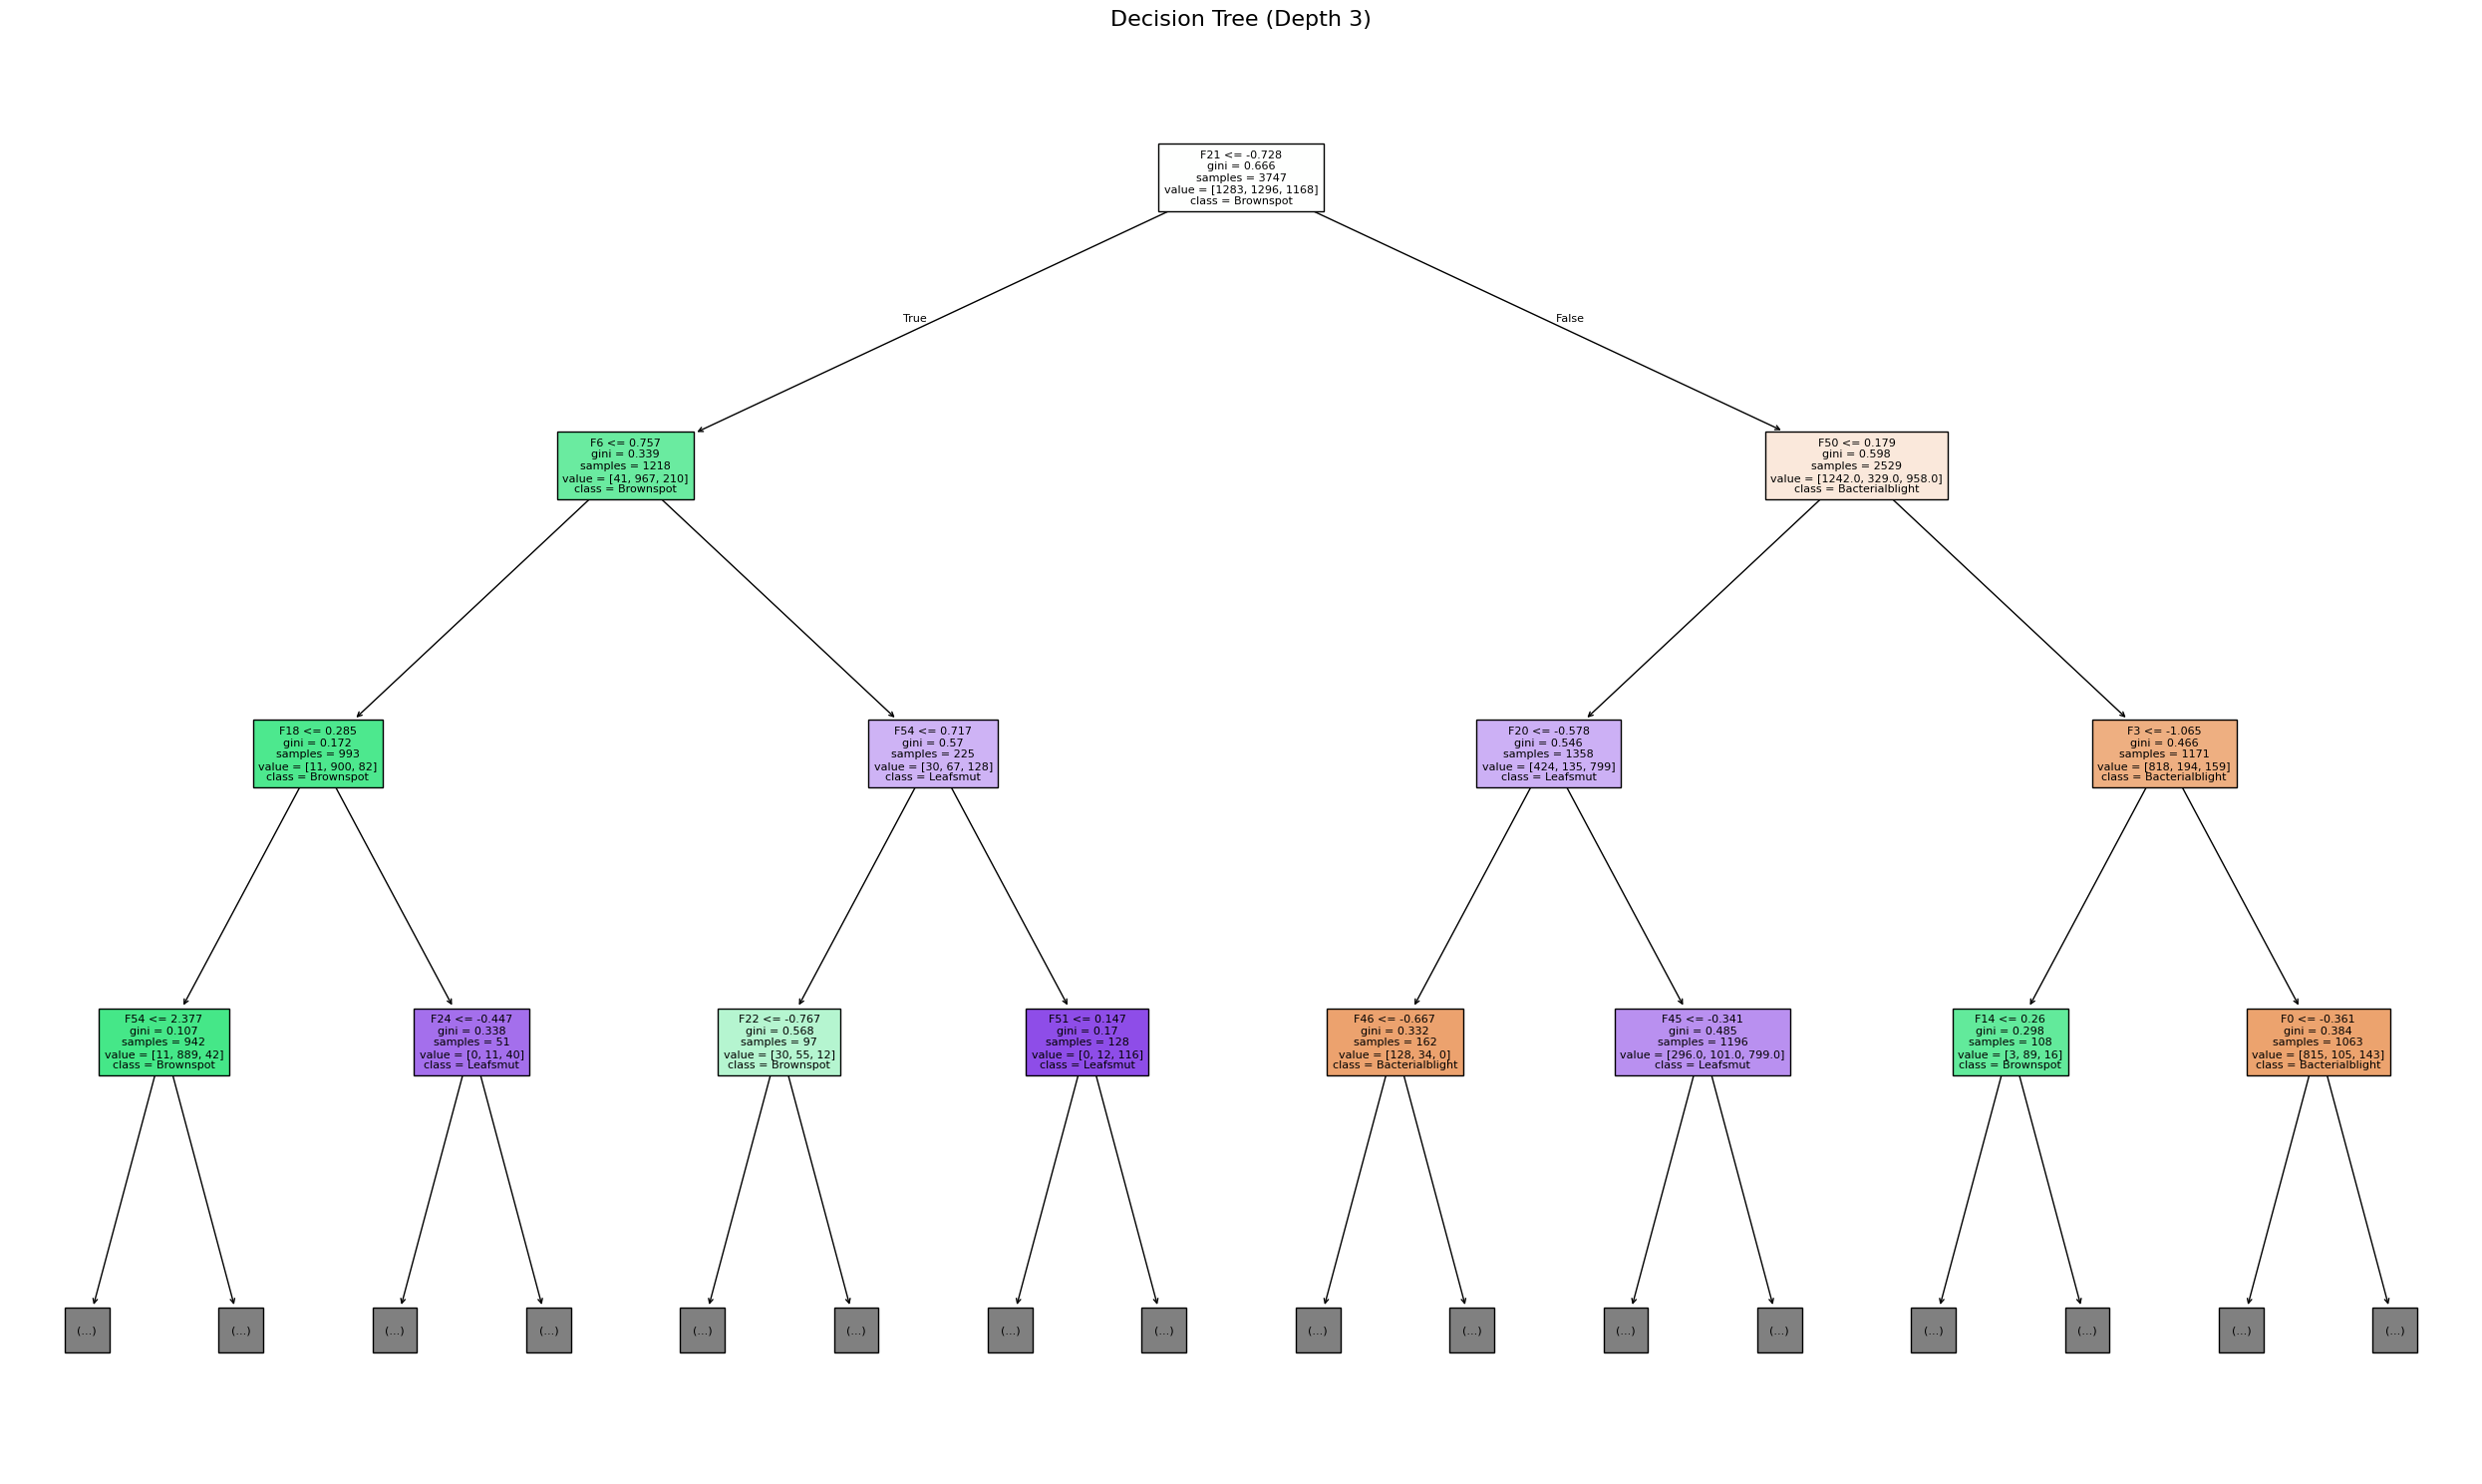

✅ Visualisasi pohon keputusan disimpan!


In [ ]:
# ========================================
# CELL 11: MODELING - DECISION TREE & KNN
# ========================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
import matplotlib.pyplot as plt
import joblib
import numpy as np
import pandas as pd

# ---- 1. LOAD DATA PREPROCESSING ----
save_path = '/content/drive/MyDrive/SEMESTER 4/KECERDASAN BUATAN /UAS Kecerdasan Buatan/Hasil/'

# Load data
X_train = np.load(save_path + 'X_train.npy')
X_test = np.load(save_path + 'X_test.npy')
y_train = np.load(save_path + 'y_train.npy')
y_test = np.load(save_path + 'y_test.npy')
scaler = joblib.load(save_path + 'scaler.pkl')
le = joblib.load(save_path + 'label_encoder.pkl')

print("✅ Data berhasil dimuat:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")

# ---- 2. MODEL 1: DECISION TREE ----
print("\n" + "="*50)
print("🌳 MODEL 1: DECISION TREE")
print("="*50)

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("✅ Decision Tree berhasil dilatih!")

# ---- 3. MODEL 2: K-NEAREST NEIGHBORS ----
print("\n" + "="*50)
print("🔍 MODEL 2: K-NEAREST NEIGHBORS (KNN)")
print("="*50)

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean',
    weights='distance'
)

knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("✅ KNN berhasil dilatih!")

# ---- 4. SIMPAN MODEL ----
joblib.dump(dt_model, save_path + 'decision_tree_model.pkl')
joblib.dump(knn_model, save_path + 'knn_model.pkl')

print(f"\n✅ Model disimpan di: {save_path}")
print("   - decision_tree_model.pkl")
print("   - knn_model.pkl")

# ---- 5. VISUALISASI POHON KEPUTUSAN ----
plt.figure(figsize=(25, 15))
tree.plot_tree(
    dt_model,
    feature_names=[f'F{i}' for i in range(X_train.shape[1])],
    class_names=le.classes_,
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title('Decision Tree (Depth 3)', fontsize=16)
plt.tight_layout()
plt.savefig(save_path + 'decision_tree_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualisasi pohon keputusan disimpan!")

📊 EVALUASI MODEL

📈 DECISION TREE
✅ Accuracy : 0.9883 (98.83%)
✅ Precision: 0.9883 (98.83%)
✅ Recall   : 0.9883 (98.83%)
✅ F1-Score : 0.9883 (98.83%)

📋 Classification Report:
                 precision    recall  f1-score   support

Bacterialblight       0.99      0.99      0.99       321
      Brownspot       0.98      0.99      0.99       324
       Leafsmut       0.99      0.98      0.98       292

       accuracy                           0.99       937
      macro avg       0.99      0.99      0.99       937
   weighted avg       0.99      0.99      0.99       937


📈 K-NEAREST NEIGHBORS (KNN)
✅ Accuracy : 1.0000 (100.00%)
✅ Precision: 1.0000 (100.00%)
✅ Recall   : 1.0000 (100.00%)
✅ F1-Score : 1.0000 (100.00%)

📋 Classification Report:
                 precision    recall  f1-score   support

Bacterialblight       1.00      1.00      1.00       321
      Brownspot       1.00      1.00      1.00       324
       Leafsmut       1.00      1.00      1.00       292

       accuracy  

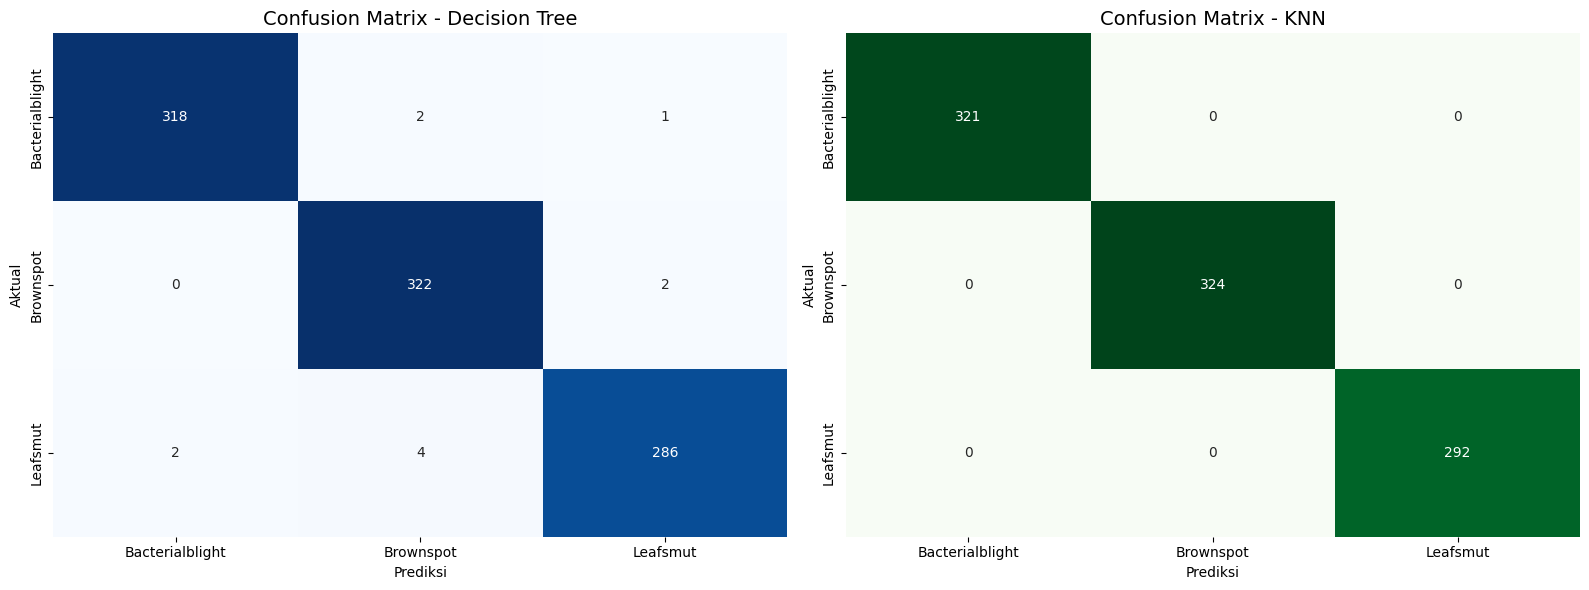


✅ Confusion matrix disimpan ke: confusion_matrices.png


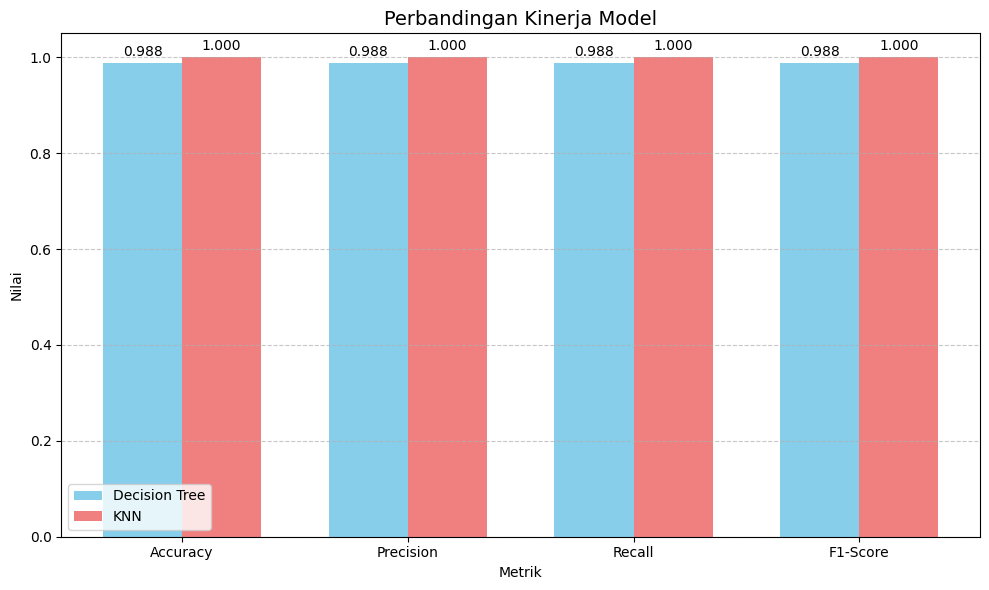


✅ Perbandingan metrik disimpan ke: model_comparison.png

🏆 MODEL TERBAIK
Decision Tree Rata-rata: 0.9883
KNN Rata-rata: 1.0000

🏆 KNN adalah model terbaik!

✅ Summary disimpan di: /content/drive/MyDrive/SEMESTER 4/KECERDASAN BUATAN /UAS Kecerdasan Buatan/Hasil/summary.json

🎉 SEMUA PROSES SELESAI!


In [ ]:
# ========================================
# CELL 12: EVALUASI MODEL
# ========================================

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("="*60)
print("📊 EVALUASI MODEL")
print("="*60)

# ---- 1. FUNCTION UNTUK EVALUASI ----
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{'='*50}")
    print(f"📈 {model_name}")
    print('='*50)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"✅ Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"✅ Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"✅ Recall   : {recall:.4f} ({recall*100:.2f}%)")
    print(f"✅ F1-Score : {f1:.4f} ({f1*100:.2f}%)")

    print("\n📋 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm
    }

# ---- 2. EVALUASI DECISION TREE ----
dt_metrics = evaluate_model(y_test, y_pred_dt, "DECISION TREE")

# ---- 3. EVALUASI KNN ----
knn_metrics = evaluate_model(y_test, y_pred_knn, "K-NEAREST NEIGHBORS (KNN)")

# ---- 4. PERBANDINGAN METRIK ----
print("\n" + "="*60)
print("📊 PERBANDINGAN KINERJA MODEL")
print("="*60)

comparison_df = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Decision Tree': [dt_metrics['accuracy'], dt_metrics['precision'], dt_metrics['recall'], dt_metrics['f1_score']],
    'KNN': [knn_metrics['accuracy'], knn_metrics['precision'], knn_metrics['recall'], knn_metrics['f1_score']]
})

# Tentukan pemenang
comparison_df['Pemenang'] = comparison_df.apply(
    lambda row: 'Decision Tree' if row['Decision Tree'] >= row['KNN'] else 'KNN',
    axis=1
)

print(comparison_df)

# ---- 5. VISUALISASI CONFUSION MATRIX ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix Decision Tree
sns.heatmap(dt_metrics['confusion_matrix'], annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax1,
            cmap='Blues', cbar=False)
ax1.set_title('Confusion Matrix - Decision Tree', fontsize=14)
ax1.set_xlabel('Prediksi')
ax1.set_ylabel('Aktual')

# Confusion Matrix KNN
sns.heatmap(knn_metrics['confusion_matrix'], annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2,
            cmap='Greens', cbar=False)
ax2.set_title('Confusion Matrix - KNN', fontsize=14)
ax2.set_xlabel('Prediksi')
ax2.set_ylabel('Aktual')

plt.tight_layout()
plt.savefig(save_path + 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Confusion matrix disimpan ke: confusion_matrices.png")

# ---- 6. VISUALISASI PERBANDINGAN METRIK ----
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison_df['Metrik']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Decision Tree'], width, label='Decision Tree', color='skyblue')
bars2 = ax.bar(x + width/2, comparison_df['KNN'], width, label='KNN', color='lightcoral')

ax.set_xlabel('Metrik')
ax.set_ylabel('Nilai')
ax.set_title('Perbandingan Kinerja Model', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metrik'])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan nilai di atas bar
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.savefig(save_path + 'model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Perbandingan metrik disimpan ke: model_comparison.png")

# ---- 7. TENTUKAN MODEL TERBAIK ----
print("\n" + "="*60)
print("🏆 MODEL TERBAIK")
print("="*60)

dt_avg = (dt_metrics['accuracy'] + dt_metrics['precision'] + dt_metrics['recall'] + dt_metrics['f1_score']) / 4
knn_avg = (knn_metrics['accuracy'] + knn_metrics['precision'] + knn_metrics['recall'] + knn_metrics['f1_score']) / 4

print(f"Decision Tree Rata-rata: {dt_avg:.4f}")
print(f"KNN Rata-rata: {knn_avg:.4f}")

if dt_avg >= knn_avg:
    print("\n🏆 DECISION TREE adalah model terbaik!")
else:
    print("\n🏆 KNN adalah model terbaik!")

# Simpan summary
summary = {
    'model_terbaik': 'Decision Tree' if dt_avg >= knn_avg else 'KNN',
    'dt_accuracy': dt_metrics['accuracy'],
    'knn_accuracy': knn_metrics['accuracy'],
    'dt_f1': dt_metrics['f1_score'],
    'knn_f1': knn_metrics['f1_score']
}

import json
with open(save_path + 'summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

print(f"\n✅ Summary disimpan di: {save_path}summary.json")
print("\n🎉 SEMUA PROSES SELESAI!")